<a href="https://colab.research.google.com/github/EmilianoCastelan/Procesos-Estocasticos/blob/main/Laberinto_y_Ser_Esc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

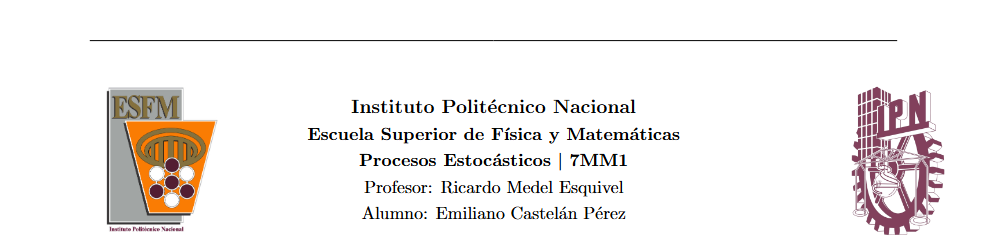

In [ ]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

##**Laberinto**

En este ejercicio primero definiremos todas las posiciones dentro del laberinto y los posibles movimientos que se pueden hacer desde cada casilla para poder crear la matriz de transiciones P

In [ ]:
Posiciones=list(range(9))

In [ ]:
P = np.zeros((9,9))

vecinos = {
    0: [1, 2],
    1: [0, 3, 7],
    2: [0, 3, 8],
    3: [1, 2, 4, 5],
    4: [3, 6],
    5: [3, 6, 8],
    6: [4, 5],
    7: [7],  # Comida
    8: [8]   # Electroshock
}

for i in vecinos:
    k = len(vecinos[i])
    for j in vecinos[i]:
        P[i][j] = 1 / k

In [ ]:
print(P)

[[0.         0.5        0.5        0.         0.         0.
  0.         0.         0.        ]
 [0.33333333 0.         0.         0.33333333 0.         0.
  0.         0.33333333 0.        ]
 [0.33333333 0.         0.         0.33333333 0.         0.
  0.         0.         0.33333333]
 [0.         0.25       0.25       0.         0.25       0.25
  0.         0.         0.        ]
 [0.         0.         0.         0.5        0.         0.
  0.5        0.         0.        ]
 [0.         0.         0.         0.33333333 0.         0.
  0.33333333 0.         0.33333333]
 [0.         0.         0.         0.         0.5        0.5
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         1.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         1.        ]]


Ya que tenemos la matriz de transición, creamos una funcón que vya haciendo los movimientos dentro del laberinto

In [ ]:
def Laberinto(alpha, P, n):
    estados = list(range(9))
    X = []

    # Estado inicial
    X0 = estados[0]
    X.append(X0)

    for i in range(1, n+1):
        j = X[i-1]

        # detener si llega a comida o shock (Estados absorbentes)
        if j in [7, 8]:
            break

        p_row = P[j]
        Xi = int(r.choices(estados, weights=p_row)[0])
        X.append(Xi)

    return X

In [ ]:
alpha = [1/7 if i not in [7,8] else 0 for i in range(9)]
trayectoria = Laberinto(alpha, P, 100)
print(trayectoria)

[0, 1, 0, 2, 3, 4, 3, 2, 0, 1, 7]


Repetimos el experimento n veces para obtener un promedio de los exitos y fracasos

In [ ]:
def Exp(reps):
  exitos=0
  fracasos=0
  for _ in range(reps):
    trayec=Laberinto(alpha, P, 100)
    if 7 in trayec:
      exitos+=1
    else:
      fracasos+=1
  return exitos/reps,fracasos/reps

In [ ]:
print(Exp(1000))

(0.419, 0.581)


Con esto, podemos concluir que la probabilidad de que el ratón llegue a la comida partiendo del estado cero es $\thickapprox$40%

##**Serpientes y escaleras**

Modelaremos este juego mediante una cadena de Markov, donde los estados son:

$S=\{0,1,2,\dots,20\}$

tal que:

Los estados $0,\dots,19$ son transitorios

El estado $20$ es absorbente.

Ahora, construimos la matriz Q, $⟹$

$Q_{ij}=P(X_{n+1}=j \mid X_n=i)$

Con esto representamos la probabilidad de pasar del estado $i$ al $j$

Recordamos que la matriz fundamental de una cadena absorbente se define como:

$N=(I-Q)^{-1}$

La entrada $N_{ij}$ representa el número esperado de veces que el proceso visita el estado $j$ comenzando desde $i$.

Además, $N = I + Q + Q^2 + Q^3 + \cdots$

Y $Q^k_{ij}$ es la probabilidad de estar en el estado $j$ después de $k$ pasos sin haber sido absorbido.

Tomando que el vector de tiempos esperados hasta finalizar el juego es $\mathbf{t}=N\mathbf{1}$

donde:

$
\mathbf{1}=
\begin{pmatrix}
1\\
1\\
\vdots\\
1
\end{pmatrix}
$

Y la componente $t_i$ representa el número esperado de tiradas para terminar el juego comenzando desde el estado $i$.

En particular $t_0$ es el número promedio de tiradas comenzando desde el inicio.

Con esto, podemos crear nuestro codigo


In [ ]:
FINAL = 20
n = FINAL

# Serpientes y escaleras
saltos = {
    3: 11,
    15: 19,
    13: 4,
    17: 9
}

# Matriz Q
Q = np.zeros((n, n))

for i in range(n):

    for d in range(1, 7):

        j = i + d

        # absorción
        if j >= FINAL:
            continue

        # aplicar serpiente/escalera
        j = saltos.get(j, j)

        Q[i, j] += 1/6

# Matriz fundamental
I = np.eye(n)

N = np.linalg.inv(I - Q)

# Tiempo esperado
ones = np.ones((n, 1))

t = N @ ones

print("Número esperado de tiradas:", t[0,0])

Número esperado de tiradas: 7.182734280990715


Ahora, por simulación definimos P

In [ ]:

FINAL = 20

# Estados: 0,1,...,20, contando el 0
n = FINAL + 1

# serpientes y escaleras
saltos = {
    3: 11,
    15: 19,
    13: 4,
    17: 9
}

# matriz de transición
P = np.zeros((n, n))

for i in range(FINAL):

    for d in range(1, 7):

        j = i + d

        # si llega o se pasa -> absorción
        if j >= FINAL:
            P[i, FINAL] += 1/6

        else:
            # aplicar serpiente/escalera
            j = saltos.get(j, j)

            P[i, j] += 1/6

# estado absorbente
P[FINAL, FINAL] = 1

np.set_printoptions(precision=3, suppress=True)

print(P)

[[0.    0.167 0.167 0.    0.167 0.167 0.167 0.    0.    0.    0.    0.167
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.167 0.    0.167 0.167 0.167 0.167 0.    0.    0.    0.167
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.167 0.167 0.167 0.167 0.167 0.    0.    0.167
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.167 0.167 0.167 0.167 0.167 0.167 0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.167 0.167 0.167 0.167 0.167 0.167 0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.167 0.167 0.167 0.167 0.167 0.167
  0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.167 0.167 0.167 0.167 0.167
  0.167 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.167 0.    0.    0.    0.167 0.167 0.167 0.167
  0.167 0.    0

In [ ]:
def Ser_esc(P, n):
  estados_se=list(range(21))
  Y=[]

  Estado_inicial=estados_se[0]
  Y.append(Estado_inicial)

  for i in range(1, n+1):

      j = Y[i-1]

      # detener si llega a la meta
      if j == 20:
            break

      # fila de probabilidades
      p_row = P[j]

      # siguiente estado
      Xi = int(r.choices(estados_se, weights=p_row)[0])

      Y.append(Xi)

  return Y

In [ ]:
trayectoria = Ser_esc(P, 100)

print(trayectoria)

[0, 11, 4, 7, 10, 16, 20]


In [33]:
def experimento(reps):
  contador=0
  for _ in range(reps):
    trayec=Ser_esc(P, 100)
    tiros=len(trayec)-1
    contador+=tiros
  return contador/reps

In [34]:
experimento(1000)

7.122

Podemos ver que el resultado es sumamente parecido, con este confirmamos que ambos métodos son confiables